# Step-by-Step Metric Computation (Single Molecule)

This notebook reproduces how metrics are computed for one molecule using:

- generated: `sample/reconstructed_mols/A.C.C.I.pickle`
- reference: `data/cremp/test/A.C.C.I.pickle`

It visualizes intermediate objects: atom maps, pairwise matrices, matrix shapes, and COV/MAT values.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem

from ringer.utils import chem as chem_utils
from ringer.utils import evaluation

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['image.cmap'] = 'magma'


In [2]:
def load_mol(path: Path):
    with open(path, "rb") as source:
        obj = pickle.load(source)
    if isinstance(obj, dict):
        return obj["rd_mol"]
    return obj

def subset_conformers(mol: Chem.Mol, max_confs: int) -> Chem.Mol:
    mol_sub = Chem.Mol(mol)
    conf_ids = [conf.GetId() for conf in mol_sub.GetConformers()]
    for conf_id in conf_ids[max_confs:]:
        mol_sub.RemoveConformer(conf_id)
    return mol_sub

def plot_matrix(mat: np.ndarray, title: str):
    plt.figure()
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label="distance")
    plt.xlabel("generated conformer index")
    plt.ylabel("reference conformer index")
    plt.title(f"{title} | shape={mat.shape} | min={mat.min():.4f}, max={mat.max():.4f}")
    plt.tight_layout()

def cov_mat_from_matrix(confusion_mat: np.ndarray, thresholds: np.ndarray):
    ref_min = confusion_mat.min(axis=1)
    gen_min = confusion_mat.min(axis=0)
    cov_r = (ref_min.reshape(-1, 1) <= thresholds.reshape(1, -1)).mean(axis=0)
    cov_p = (gen_min.reshape(-1, 1) <= thresholds.reshape(1, -1)).mean(axis=0)
    mat_r = ref_min.mean()
    mat_p = gen_min.mean()
    return ref_min, gen_min, cov_r, cov_p, mat_r, mat_p


## 1) Load both molecules and inspect basic sizes

In [3]:
gen_path = Path("sample/reconstructed_mols/A.C.C.I.pickle")
ref_path = Path("data/cremp/test/A.C.C.I.pickle")

mol_gen = load_mol(gen_path)
mol_ref = load_mol(ref_path)

print(f"Generated path: {gen_path}")
print(f"Reference path: {ref_path}")
print(f"Generated atoms (with H): {mol_gen.GetNumAtoms()}")
print(f"Reference atoms (with H): {mol_ref.GetNumAtoms()}")
print(f"Generated conformers: {mol_gen.GetNumConformers()}")
print(f"Reference conformers: {mol_ref.GetNumConformers()}")


Generated path: sample/reconstructed_mols/A.C.C.I.pickle
Reference path: data/cremp/test/A.C.C.I.pickle
Generated atoms (with H): 51
Reference atoms (with H): 51
Generated conformers: 1008
Reference conformers: 504


## 2) Remove hydrogens (as in evaluation) and cap conformers for interactive runtime

The production scripts remove hydrogens before RMSD/TFD.
You can increase caps to use all conformers.

In [4]:
MAX_REF_CONFS = 15
MAX_GEN_CONFS = 30

ref_noh = Chem.RemoveHs(mol_ref)
gen_noh = Chem.RemoveHs(mol_gen)

ref_noh = subset_conformers(ref_noh, min(MAX_REF_CONFS, ref_noh.GetNumConformers()))
gen_noh = subset_conformers(gen_noh, min(MAX_GEN_CONFS, gen_noh.GetNumConformers()))

print(f"Reference atoms (no H): {ref_noh.GetNumAtoms()}")
print(f"Generated atoms (no H): {gen_noh.GetNumAtoms()}")
print(f"Reference conformers used: {ref_noh.GetNumConformers()}")
print(f"Generated conformers used: {gen_noh.GetNumConformers()}")


Reference atoms (no H): 25
Generated atoms (no H): 25
Reference conformers used: 15
Generated conformers used: 30


## 3) Build atom mappings with symmetry (`GetSubstructMatches`)

In [5]:
atom_maps = evaluation.get_atom_map(gen_noh, ref_noh)
print(f"Number of atom maps: {len(atom_maps)}")
if atom_maps:
    first_map_df = pd.DataFrame(list(atom_maps[0].items()), columns=["generated_atom", "reference_atom"])
    display(first_map_df.head(15))


Number of atom maps: 1


,generated_atom,reference_atom
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5
6,6,6
7,7,7
8,8,8
9,9,9


## 4) All-atom RMSD matrix (`rmsd`)

,0,1,2,3,4,5,6,7,8,9
0,0.521455,2.284018,2.333919,2.330907,0.099863,0.815098,2.308336,2.420143,0.114417,0.100829
1,0.747564,2.306276,2.245643,2.244498,0.516224,0.688946,2.347738,2.440412,0.488448,0.508107
2,0.761953,2.302347,2.238492,2.237495,0.535472,0.689945,2.343978,2.436042,0.508866,0.527757
3,0.762511,2.300252,2.236605,2.235593,0.534887,0.689696,2.342180,2.434081,0.508338,0.527202
4,0.486114,2.416438,2.470510,2.467619,0.576970,0.623200,2.355555,2.541672,0.595149,0.577290
5,0.114081,2.346820,2.415413,2.413234,0.554219,0.761713,2.262788,2.476087,0.552916,0.555787
6,0.668906,2.411702,2.366541,2.365381,0.736474,0.395535,2.362291,2.534519,0.729970,0.731469
7,0.481585,2.416088,2.461358,2.458450,0.573504,0.593379,2.357355,2.542179,0.587619,0.572717
8,2.393384,0.497255,0.102000,0.100243,2.318191,2.403127,0.771743,0.734649,2.308415,2.318835
9,0.506759,2.261860,2.314491,2.311547,0.114226,0.836995,2.284907,2.399265,0.115521,0.116541


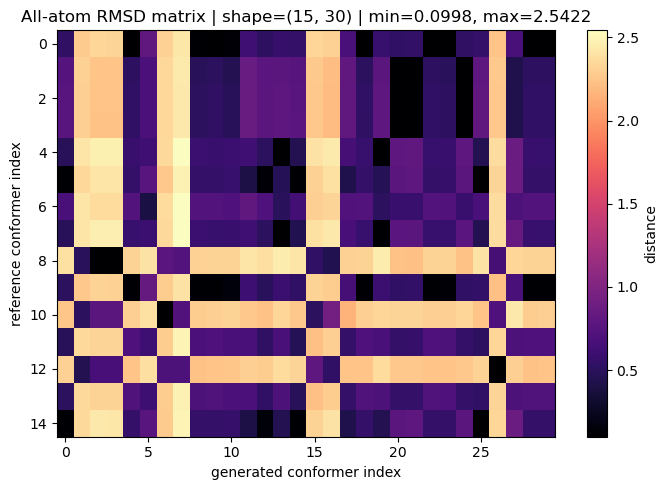

In [6]:
atom_map_pairs = [list(m.items()) for m in atom_maps]
rmsd_mat = evaluation.compute_rmsd_matrix_from_map(
    gen_noh,
    ref_noh,
    atom_map_pairs,
    ncpu=1,
)

plot_matrix(rmsd_mat, "All-atom RMSD matrix")
display(pd.DataFrame(rmsd_mat[:10, :10]))


## 5) Ring-only RMSD matrix (`ring-rmsd`)

Generated ring atoms: 12
Reference ring atoms: 12
Ring-only atom map count: 1


,0,1,2,3,4,5,6,7,8,9
0,0.011214,1.372432,1.375409,1.376240,0.008212,0.021175,1.377566,1.371963,0.014101,0.008377
1,0.013358,1.372878,1.375844,1.376673,0.010250,0.021750,1.378017,1.372430,0.015244,0.010533
2,0.018555,1.373102,1.376048,1.376877,0.016025,0.026158,1.378255,1.372668,0.018742,0.015434
3,0.018280,1.372097,1.375042,1.375871,0.015898,0.025118,1.377253,1.371665,0.017993,0.015197
4,0.012232,1.363348,1.366367,1.367205,0.013730,0.009843,1.368493,1.362845,0.013193,0.012900
5,0.006821,1.368128,1.371116,1.371948,0.005883,0.014299,1.373259,1.367663,0.009415,0.006187
6,0.014829,1.362251,1.365255,1.366092,0.015857,0.007267,1.367411,1.361775,0.013910,0.014983
7,0.018806,1.359936,1.362930,1.363766,0.019977,0.010759,1.365108,1.359455,0.016111,0.018570
8,1.372688,0.012109,0.009408,0.008716,1.374535,1.367312,0.009038,0.020286,1.370185,1.373789
9,0.010237,1.365355,1.368332,1.369159,0.010859,0.016420,1.370509,1.364923,0.005563,0.010010


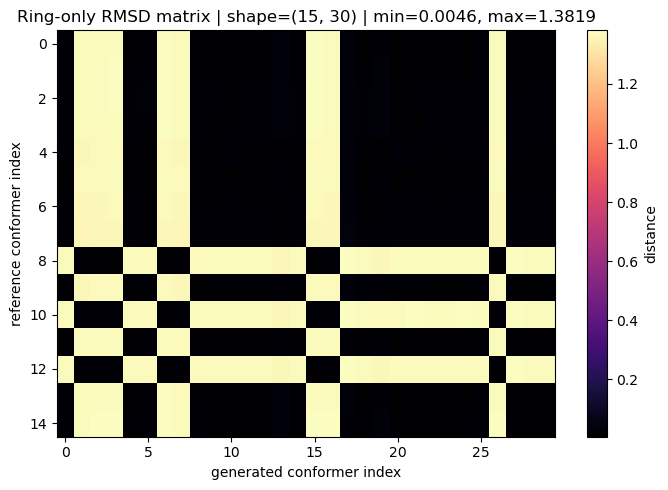

In [7]:
gen_ring_idxs = chem_utils.get_macrocycle_idxs(gen_noh, n_to_c=False)
ref_ring_idxs = chem_utils.get_macrocycle_idxs(ref_noh, n_to_c=False)
print("Generated ring atoms:", len(gen_ring_idxs))
print("Reference ring atoms:", len(ref_ring_idxs))

ring_atom_maps = list(
    set(tuple((k, atom_map[k]) for k in gen_ring_idxs) for atom_map in atom_maps)
)
print("Ring-only atom map count:", len(ring_atom_maps))

ring_rmsd_mat = evaluation.compute_rmsd_matrix_from_map(
    gen_noh,
    ref_noh,
    ring_atom_maps,
    ncpu=1,
)

plot_matrix(ring_rmsd_mat, "Ring-only RMSD matrix")
display(pd.DataFrame(ring_rmsd_mat[:10, :10]))


## 6) Ring-only TFD matrix (`ring-tfd`)

,0,1,2,3,4,5,6,7,8,9
0,0.002884,0.642760,0.642013,0.641755,0.001790,0.005134,0.641361,0.643060,0.003540,0.001810
1,0.003452,0.642673,0.641926,0.641668,0.002472,0.005523,0.641274,0.642973,0.003896,0.002363
2,0.004896,0.642499,0.641751,0.641494,0.003791,0.006880,0.641100,0.642799,0.005111,0.003820
3,0.004844,0.642783,0.642036,0.641778,0.003822,0.006580,0.641384,0.643083,0.005019,0.003853
4,0.003969,0.645182,0.644434,0.644177,0.003559,0.002471,0.643782,0.645482,0.005124,0.003332
5,0.001936,0.644082,0.643334,0.643077,0.001912,0.004248,0.642682,0.644381,0.003110,0.001678
6,0.004596,0.645464,0.644716,0.644459,0.004113,0.001302,0.644064,0.645764,0.005747,0.004061
7,0.005522,0.646100,0.645352,0.645094,0.005609,0.002845,0.644700,0.646399,0.005692,0.005042
8,0.642831,0.002472,0.001612,0.001436,0.642306,0.644167,0.002102,0.004823,0.643460,0.642455
9,0.002745,0.644783,0.644036,0.643778,0.002844,0.006248,0.643384,0.645083,0.001748,0.002912


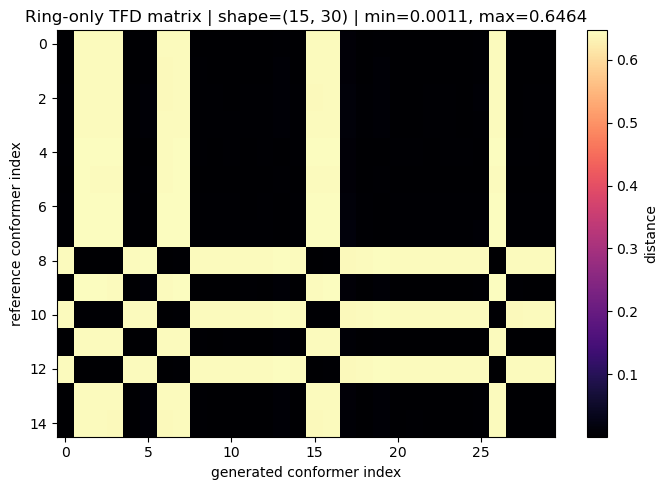

In [8]:
ring_tfd_mat = evaluation.compute_ring_tfd_matrix(gen_noh, ref_noh, ncpu=1)
plot_matrix(ring_tfd_mat, "Ring-only TFD matrix")
display(pd.DataFrame(ring_tfd_mat[:10, :10]))


## 7) Derive COV/MAT from one matrix (manual and library check)

In [9]:
thresholds_demo = np.array([0.05, 0.10, 0.25, 0.50])

ref_min, gen_min, cov_r, cov_p, mat_r, mat_p = cov_mat_from_matrix(ring_rmsd_mat, thresholds_demo)
manual_df = pd.DataFrame({"threshold": thresholds_demo, "cov-r": cov_r, "cov-p": cov_p})
manual_df["mat-r"] = mat_r
manual_df["mat-p"] = mat_p
print("Manual computation:")
display(manual_df)

lib = evaluation.compute_cov_mat_metrics(ring_rmsd_mat, thresholds=thresholds_demo)
lib_df = pd.DataFrame(lib["cov"])
lib_df["mat-r"] = lib["mat"]["mat-r"]
lib_df["mat-p"] = lib["mat"]["mat-p"]
print("Library output (should match):")
display(lib_df)

print("ref_min length:", len(ref_min), "gen_min length:", len(gen_min))
print("ref_min describe:")
display(pd.Series(ref_min).describe())
print("gen_min describe:")
display(pd.Series(gen_min).describe())


Manual computation:


,threshold,cov-r,cov-p,mat-r,mat-p
0,0.05,1.0,1.0,0.007852,0.008711
1,0.10,1.0,1.0,0.007852,0.008711
2,0.25,1.0,1.0,0.007852,0.008711
3,0.50,1.0,1.0,0.007852,0.008711


Library output (should match):


,threshold,cov-r,cov-p,mat-r,mat-p
0,0.05,1.0,1.0,0.007852,0.008711
1,0.10,1.0,1.0,0.007852,0.008711
2,0.25,1.0,1.0,0.007852,0.008711
3,0.50,1.0,1.0,0.007852,0.008711


ref_min length: 15 gen_min length: 30
ref_min describe:


count    15.000000
mean      0.007852
std       0.002015
min       0.004613
25%       0.005928
50%       0.007787
75%       0.009655
max       0.010759
dtype: float64

gen_min describe:


count    30.000000
mean      0.008711
std       0.004225
min       0.004613
25%       0.006234
50%       0.007153
75%       0.009432
max       0.022776
dtype: float64

## 8) Full COV curves for all three metrics

,mat-r,mat-p
rmsd,0.171706,0.203150
ring-rmsd,0.007852,0.008711
ring-tfd,0.001895,0.002225


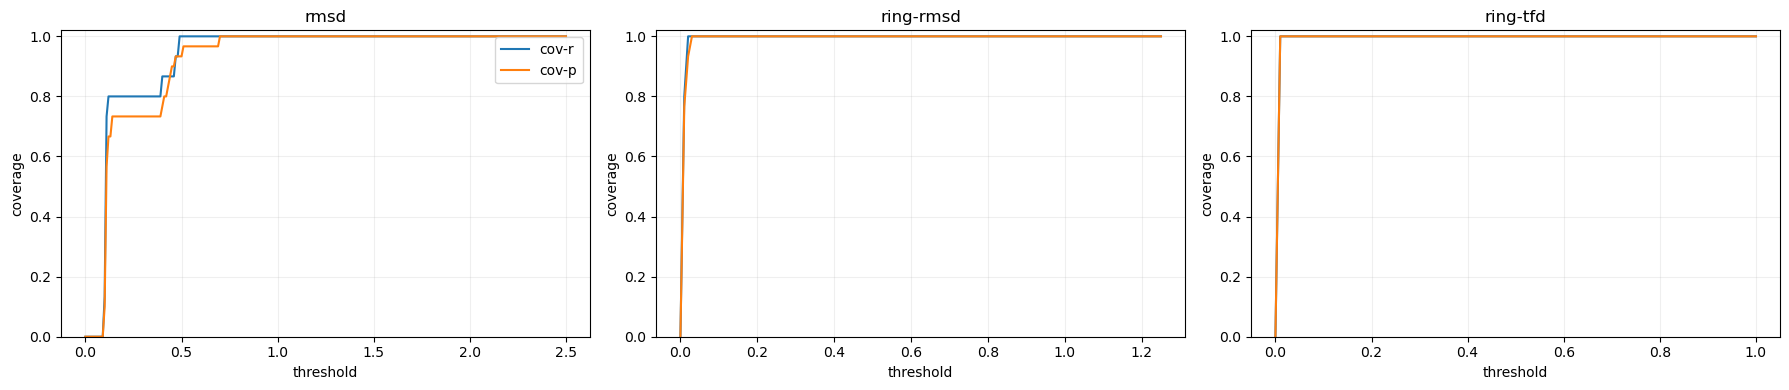

In [10]:
thresholds_rmsd = evaluation.CovMatEvaluator.thresholds["rmsd"]
thresholds_rrmsd = evaluation.CovMatEvaluator.thresholds["ring-rmsd"]
thresholds_rtfd = evaluation.CovMatEvaluator.thresholds["ring-tfd"]

covmat_rmsd = evaluation.compute_cov_mat_metrics(rmsd_mat, thresholds=thresholds_rmsd)
covmat_rrmsd = evaluation.compute_cov_mat_metrics(ring_rmsd_mat, thresholds=thresholds_rrmsd)
covmat_rtfd = evaluation.compute_cov_mat_metrics(ring_tfd_mat, thresholds=thresholds_rtfd)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, name, metrics in [
    (axes[0], "rmsd", covmat_rmsd),
    (axes[1], "ring-rmsd", covmat_rrmsd),
    (axes[2], "ring-tfd", covmat_rtfd),
]:
    th = metrics["cov"]["threshold"]
    ax.plot(th, metrics["cov"]["cov-r"], label="cov-r")
    ax.plot(th, metrics["cov"]["cov-p"], label="cov-p")
    ax.set_title(name)
    ax.set_xlabel("threshold")
    ax.set_ylabel("coverage")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.2)
axes[0].legend()
plt.tight_layout()

mat_df = pd.DataFrame(
    {
        "rmsd": covmat_rmsd["mat"],
        "ring-rmsd": covmat_rrmsd["mat"],
        "ring-tfd": covmat_rtfd["mat"],
    }
).T
display(mat_df)


## 9) Values at common thresholds (0.75, 0.10, 0.05)

In [11]:
def pick_threshold(metrics, target):
    th = np.asarray(metrics["cov"]["threshold"])
    idx = int(np.argmin(np.abs(th - target)))
    return float(th[idx]), float(metrics["cov"]["cov-r"][idx]), float(metrics["cov"]["cov-p"][idx])

rows = []
for name, target, metrics in [
    ("rmsd", 0.75, covmat_rmsd),
    ("ring-rmsd", 0.10, covmat_rrmsd),
    ("ring-tfd", 0.05, covmat_rtfd),
]:
    used, cov_r, cov_p = pick_threshold(metrics, target)
    rows.append({
        "metric": name,
        "threshold_requested": target,
        "threshold_used": used,
        "cov-r": cov_r,
        "cov-p": cov_p,
        "mat-r": metrics["mat"]["mat-r"],
        "mat-p": metrics["mat"]["mat-p"],
    })

display(pd.DataFrame(rows))


,metric,threshold_requested,threshold_used,cov-r,cov-p,mat-r,mat-p
0,rmsd,0.75,0.75,1.0,1.0,0.171706,0.203150
1,ring-rmsd,0.10,0.10,1.0,1.0,0.007852,0.008711
2,ring-tfd,0.05,0.05,1.0,1.0,0.001895,0.002225
